# Semana 5 — Modelos globales y cross-learning

**Objetivo.** Entrenar un modelo compartido entre muchas series, medir generalización a clientes no vistos y trabajar de forma eficiente con 9.7 millones de filas.

- **Dataset:** `data/05_electricity/electricity_long.csv`
- **Duración:** 5 horas
- **Frecuencia:** horaria; 370 clientes
- **Seed:** 42

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

## Caso de negocio: planificar capacidad con clientes nuevos

Una empresa de energía debe **planificar capacidad y dimensionar recursos** (compra de energía, mantenimiento de red, contratos de suministro) para sus 370 clientes. El reto operativo no son los clientes históricos, sino los **clientes nuevos**: en el momento del alta no existe historial de consumo de ese cliente y, aun así, se necesita un pronóstico desde el primer día.

Este escenario se denomina **cold-start**: predecir sin historia del sujeto. La pregunta de negocio no es solo "¿cuánto consumirá este cliente la próxima hora?", sino "¿con qué precisión podemos comprometer capacidad para un cliente del que solo conocemos su tipo y su fecha de alta?".

El dataset Electricity (370 clientes, frecuencia horaria) permite simular el problema con datos reales: se entrena con 296 clientes y se evalúa con 74 clientes **completamente nuevos** (ninguna de sus filas aparece en train). Lo que aprendamos aquí define la política de despliegue para altas de nuevos suministros.

> *Este notebook modela consumo eléctrico agregado por cliente (kWh/hora), no comportamiento de electrodomésticos individuales ni decisiones de hogares específicos. Las conclusiones aplican a segmentación y pronóstico de cartera, no a intervenciones sobre consumo residencial individual.*

## Pregunta guía

**¿Cuándo un modelo global ayuda y cuándo no?**

Mantenga esta pregunta abierta a lo largo del notebook. Al final debería poder responderla con argumentos basados en los resultados que verá: qué gana un modelo compartido (transferir la forma del consumo), qué no puede recuperar (la escala individual sin contexto) y en qué condiciones conviene un modelo local con historia.

### 0.1 Imports y seed

Lectura por chunks y modelos CPU.

**¿Qué hace esta celda?** Configura el entorno de ejecución. `SEED=42` fija todas las fuentes de aleatoriedad: el split por cliente, el clustering (KMeans) y los modelos (LightGBM) usarán `random_state=SEED`, de modo que cada ejecución produce los mismos resultados.

**¿Por qué importa?** El forecasting multi-serie tiene dos fuentes de aleatoriedad: la selección de clientes de test y la inicialización de los modelos. Sin semilla, cada ejecución elegiría un conjunto distinto de clientes "nuevos" y sería imposible comparar notebooks o reproducir un resultado. `warnings.filterwarnings("ignore")` silencia avisos de convergencia que no afectan la didáctica.

In [1]:
from __future__ import annotations
from pathlib import Path
import random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from lightgbm import LGBMRegressor
SEED=42
random.seed(SEED); np.random.seed(SEED); warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(12,4)

### 0.2 Ruta y tamaño

No se carga el CSV completo sin estimar memoria.

**¿Qué hace esta celda?** Localiza el CSV dentro del repositorio probando dos rutas candidatas (raíz del curso o subdirectorio `..`). Si el archivo no existe, el `assert` detiene el notebook: el material es autocontenido y no debe descargar nada.

**¿Por qué importa?** El dataset completo ocupa 403.2 MiB en disco; cargarlo a ciegas con `pd.read_csv` sería lento y consumiría mucha RAM. Primero medimos el archivo, luego estimamos memoria y solo entonces decidimos cómo leerlo.

In [2]:
CANDIDATES=[Path("data/05_electricity/electricity_long.csv"),Path("../data/05_electricity/electricity_long.csv")]
DATA_PATH=next((p for p in CANDIDATES if p.exists()),None); assert DATA_PATH
print(DATA_PATH.resolve(),f"{DATA_PATH.stat().st_size/2**20:.1f} MiB")

/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/05_electricity/electricity_long.csv 403.2 MiB


### 0.3 Estimación de memoria

Pandas puede requerir varias veces el tamaño en disco por strings y temporales.

**Interpretación.** Con 403.2 MiB en disco, la estimación conservadora es 806–1613 MiB de RAM (2–4×). Es manejable en un portátil, pero confirma que conviene leer por bloques en lugar de una sola pasada.

**Nota sobre los datos.** El CSV completo contiene 9,732,480 filas (370 clientes × 26,304 horas). Este notebook usa deliberadamente **los últimos 120 días por serie** (ventana de 1,065,600 filas) para que el laboratorio corra en CPU. No es un submuestreo aleatorio: es una ventana temporal explícita que se documenta en la celda siguiente.

**Alternativas de carga (discusión, no se ejecutan aquí).** En producción se podría convertir el CSV a Parquet con particionado por cliente, usar tipos de precisión reducida (el notebook ya usa `float32` y `category`) o perfilado de memoria con `DataFrame.memory_usage`. Son optimizaciones de ingeniería de datos; no cambian la lección metodológica de esta semana.

In [3]:
disk_mib=DATA_PATH.stat().st_size/2**20; print(f"Disco={disk_mib:.1f} MiB; estimación RAM conservadora 2–4×={2*disk_mib:.0f}–{4*disk_mib:.0f} MiB")

Disco=403.2 MiB; estimación RAM conservadora 2–4×=806–1613 MiB


### 0.4 Lectura chunked

Se construyen perfiles y se retienen solo los últimos 120 días para el laboratorio. No es subsampling aleatorio: es una ventana temporal explícita para CPU.

**¿Qué hace esta celda?** Lee el CSV en bloques de 500,000 filas (`chunksize=CHUNK`). Por cada bloque acumula un resumen por cliente (`count`, `mean`, `std`, `min`, `max`) y conserva solo las filas con `ds >= cutoff` (2014-09-03). Al final, `profile` resume la historia completa de cada cliente y `window` contiene la ventana de laboratorio.

**¿Por qué importa?** El perfil completo se necesita para el EDA (escalas, volatilidad) aunque no se modele toda la historia. El corte temporal evita que la memoria crezca sin límite y es transparente: el `cutoff` queda documentado y reproducible.

In [4]:
CHUNK=500_000; cutoff=pd.Timestamp("2014-09-03"); parts=[]; summaries=[]; total=0
for chunk in pd.read_csv(DATA_PATH,chunksize=CHUNK,parse_dates=["ds"],dtype={"unique_id":"category","y":"float32"}):
    total+=len(chunk); summaries.append(chunk.groupby("unique_id",observed=True).y.agg(["count","mean","std","min","max"])); parts.append(chunk.loc[chunk.ds>=cutoff].copy())
window=pd.concat(parts,ignore_index=True); profile=pd.concat(summaries).groupby(level=0).agg({"count":"sum","mean":"mean","std":"mean","min":"min","max":"max"})
print("filas totales",total,"ventana",window.shape,"series",window.unique_id.nunique())

filas totales 9732480 ventana (1065600, 3) series 370


### 0.5 Contrato

Se verifican 9,732,480 filas, 370 series y esquema.

**¿Qué valida esta celda?** Tres aserciones: (1) el número total de filas leídas coincide con el contrato del dataset; (2) hay exactamente 370 clientes; (3) el esquema es exactamente `ds`, `unique_id`, `y` y el target no tiene nulos. Si alguna falla, el notebook se detiene antes de modelar: los tests son baratos y evitan análisis sobre datos corruptos o con un esquema distinto al esperado.

In [5]:
assert total==9_732_480 and window.unique_id.nunique()==370
assert set(window.columns)=={"ds","unique_id","y"}; assert window.y.notna().all()
print(window.dtypes)

ds           datetime64[ns]
unique_id            object
y                   float32
dtype: object


### 0.6 Rango

Ventana usada y rango global inferido del streaming.

**Interpretación.** `window` va de 2014-09-03 a 2014-12-31 (2,880 horas = 120 días × 24 h). El `profile` muestra la historia completa por cliente: `MT_001` promedia 21.2 kWh/h mientras `MT_004` promedia 438.2 kWh/h. La escala difiere por un factor mayor que 20 entre clientes, lo que anticipa por qué una métrica absoluta como MAE debe leerse con cuidado y por qué conviene una métrica normalizada por serie (MASE).

In [6]:
print(window.ds.min(),window.ds.max(),window.ds.nunique()); print(profile.head())

2014-09-03 00:00:00 2014-12-31 23:00:00 2880
           count        mean         std  min          max
unique_id                                                 
MT_001     26304   21.172592   24.176884  0.0   138.324875
MT_002     26304  110.739204   25.588779  0.0   293.029877
MT_003     26304   15.560692   49.092941  0.0   598.609924
MT_004     26304  438.210510  152.777817  0.0  1168.699219
MT_005     26304  198.566467   69.770607  0.0   545.121948


### 0.7 Duplicados

La clave serie-tiempo debe ser única.

**¿Por qué importa?** En un panel long, un par `(unique_id, ds)` duplicado rompería los `shift` de los lags y el orden temporal dentro de cada cliente. El resultado 0 confirma que la clave es válida y que podemos agrupar por cliente sin ambigüedad.

In [7]:
print("duplicados clave en ventana:",window.duplicated(["unique_id","ds"]).sum())

duplicados clave en ventana: 0


### 0.8 Distribución por serie

Escalas heterogéneas justifican normalización/MAPE cauteloso.

**Interpretación.** La media de las medias por cliente es 2,348.5, pero la mediana ronda los 488 y el cliente de mayor escala promedia 190,542 (columna `max`). Esta cola pesada explica por qué las métricas agregadas quedan dominadas por pocos clientes grandes y por qué `MASE` (normalizada por serie) complementa a `MAE` en todo el notebook.

In [8]:
profile[["mean","std","max"]].describe(percentiles=[.1,.5,.9,.99])

,mean,std,max
count,370.000000,370.000000,370.000000
mean,2348.518799,1095.035555,6339.207520
std,11425.999023,7273.570485,41859.527344
min,4.361776,8.436203,82.914574
10%,83.495366,46.643961,356.548627
50%,488.404572,197.571915,1147.785767
90%,3649.811938,1373.025269,7959.642920
99%,31877.745313,10285.769729,58102.772656
max,190542.375000,131611.179295,764000.000000


## 1. Análisis previo (pre-modeling)

EDA de panel: perfiles, volatilidad, clustering y diagnóstico sobre la serie agregada.

**¿Qué buscamos?** Responder tres preguntas antes de modelar: (1) ¿qué tan heterogéneas son las escalas entre clientes? (2) ¿existen grupos de clientes con forma de consumo similar (candidatos a segmentos)? (3) ¿qué estructura temporal tiene el agregado (estacionalidad, estacionariedad, outliers)? Las respuestas condicionan el diseño de features y la lectura de métricas.

### 1.1 Series más volátiles

Coeficiente de variación con media positiva.

**Interpretación.** `cv = std/mean` relativiza la dispersión respecto a la escala del cliente. `MT_003` tiene cv ≈ 3.15: su desviación triplica su consumo medio, un comportamiento errático que probablemente lo convierta en un cliente "difícil" en la evaluación.

**Implicación operativa.** La heterogeneidad de escala entre clientes (de ≈4.36 a ≈190,542 en la media por serie, razón ≈43,700×) significa que un mismo error absoluto es trivial para un cliente pequeño y catastrófico para uno grande. Las métricas macro (mediana de MASE) protegen contra la dominación de los clientes grandes, pero la decisión operativa debe considerar el costo relativo por segmento, no solo la métrica agregada.

In [9]:
profile["cv"]=profile["std"]/(profile["mean"].abs()+1e-6); profile.sort_values("cv",ascending=False).head(10)

,count,mean,std,min,max,cv
unique_id,,,,,,
MT_003,26304,15.560692,49.092941,0.0,598.609924,3.154933
MT_178,26304,275.266876,697.065796,0.0,3423.519043,2.532327
MT_093,26304,104.150146,237.753494,0.0,1058.883301,2.282796
MT_160,26304,6.184965,13.949923,0.0,226.995911,2.255457
MT_133,26304,4.361776,9.715525,0.0,96.904442,2.227423
MT_110,26304,30.195078,66.225037,0.0,736.772461,2.193239
MT_223,26304,721.620117,1337.916626,0.0,5178.666504,1.854046
MT_109,26304,83.074493,150.805206,0.0,957.446838,1.815301
MT_112,26304,40.945694,73.351242,0.0,410.339264,1.791427


### 1.2 Series más estables

Menor CV no implica mayor predictibilidad absoluta.

**Interpretación.** `MT_148` tiene cv ≈ 0.077 (muy estable en términos relativos) pero un consumo medio de 1,372.8. La estabilidad relativa ayuda a que el MASE sea bajo, pero el error absoluto puede seguir siendo grande si la escala es alta.

In [10]:
profile.sort_values("cv").head(10)

,count,mean,std,min,max,cv
unique_id,,,,,,
MT_148,26304,1372.767456,105.347900,0.0,2753.830322,0.076741
MT_145,26304,309.335754,24.681887,0.0,607.206116,0.079790
MT_149,26304,93.877335,8.436203,0.0,241.851364,0.089864
MT_147,26304,10936.395508,1032.174927,0.0,21336.585938,0.094380
MT_146,26304,333.837128,41.889275,0.0,739.944885,0.125478
MT_163,26304,9350.999023,1381.189209,0.0,18368.664062,0.147705
MT_154,26304,132.960449,20.695688,0.0,292.502655,0.155653
MT_150,26304,109.811501,17.122593,0.0,223.990204,0.155927
MT_369,26304,3333.889648,552.760554,0.0,6032.258301,0.165800


### 1.3 Escalas

Distribución log de consumo medio.

**Interpretación.** El histograma en escala log(1+media) muestra una distribución con cola larga: pocos clientes concentran la mayor parte del consumo. Para un modelo global, esta heterogeneidad implica que la pérdida agregada será dominada por los clientes grandes; por eso el notebook reporta también métricas por serie y macro.

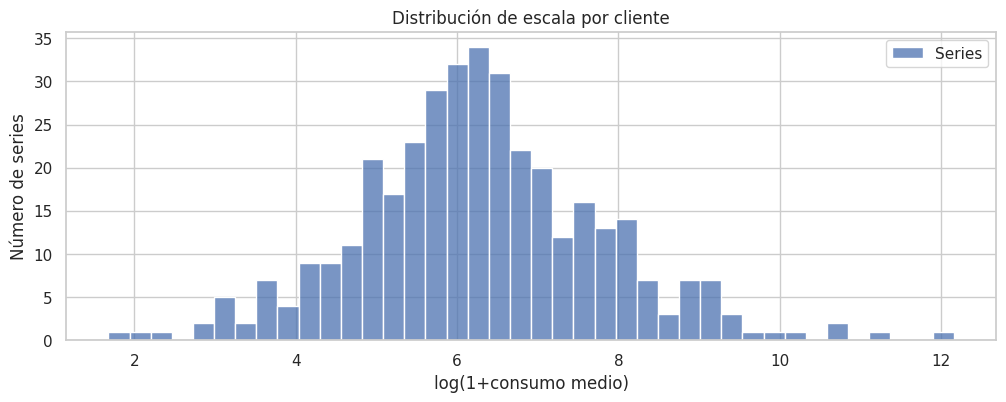

In [11]:
fig,ax=plt.subplots(); sns.histplot(np.log1p(profile["mean"]),bins=40,ax=ax,label="Series"); ax.set(title="Distribución de escala por cliente",xlabel="log(1+consumo medio)",ylabel="Número de series"); ax.legend(); plt.show()

### 1.4 Perfiles horarios

Matriz serie × hora normalizada por media.

**¿Qué hace esta celda?** Calcula el consumo medio por hora de cada cliente y lo divide por su media total: cada fila queda en unidades *relativas al cliente*. Así se compara la forma del consumo (picos de mañana o tarde) sin que la escala interfiera. Esta matriz es la materia prima del clustering.

In [12]:
hour_profile=window.assign(hour=window.ds.dt.hour).pivot_table(index="unique_id",columns="hour",values="y",aggfunc="mean"); normalized=hour_profile.div(hour_profile.mean(axis=1).replace(0,np.nan),axis=0).fillna(0); normalized.head()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
unique_id,,,,,,,,,,,,,,,,,,,,,
MT_001,1.037604,1.087966,1.071179,1.101555,1.113546,1.077574,1.160710,1.122339,0.996036,1.270226,...,0.863338,1.031209,0.890517,0.822569,0.976851,1.012024,1.044000,1.004030,0.986444,0.996036
MT_002,0.879407,0.784795,0.741923,0.730882,0.748970,0.810401,0.890859,1.119609,1.138050,1.148445,...,1.067399,1.024938,1.019711,1.029460,1.082903,1.157959,1.152849,1.075621,0.983475,0.931735
MT_003,1.015060,0.870052,0.850860,0.978808,0.996934,1.051313,1.015060,1.015060,1.051313,1.068372,...,0.942556,0.942556,1.015060,1.053445,1.183526,1.033187,1.122751,1.015060,1.015060,1.015060
MT_004,1.035545,0.884951,0.795082,0.772249,0.747080,0.745337,0.741259,0.759142,0.808434,0.848697,...,0.839877,0.835415,0.865325,0.989670,1.305081,1.598183,1.618820,1.494788,1.352003,1.168710
MT_005,1.082647,0.973175,0.883692,0.844091,0.832674,0.839875,0.857259,0.854228,0.811168,0.769198,...,0.814626,0.881939,0.923294,1.075163,1.302114,1.412770,1.412202,1.389275,1.367058,1.278855


### 1.5 Clustering

K-means k=4 sobre perfiles horarios estandarizados.

**¿Qué hace esta celda?** Estandariza los perfiles horarios y agrupa con K-means (k=4, semilla fija, 20 reinicios). El resultado (`clusters`) asigna cada cliente a un segmento de forma de consumo. El silhouette de 0.40 indica separación moderada: los grupos son interpretables, aunque no perfectamente definidos. Tamaños: 213/119/34/4 clientes.

In [13]:
scaler=StandardScaler(); Z=scaler.fit_transform(normalized); km=KMeans(n_clusters=4,random_state=SEED,n_init=20).fit(Z); clusters=pd.Series(km.labels_,index=normalized.index,name="cluster"); print(clusters.value_counts().sort_index()); print("silhouette",silhouette_score(Z,km.labels_))

cluster
0    213
1    119
2     34
3      4
Name: count, dtype: int64
silhouette 0.4004967


### 1.6 Centroides

Forma media por cluster.

**Interpretación.** Los centroides muestran el patrón horario típico de cada grupo (p. ej., picos en horas laborables frente a consumo plano). Estos segmentos son la base de la política de producción: el perfil hora×día puede calcularse **por segmento** para clientes nuevos, como se discute en la Sección 3.

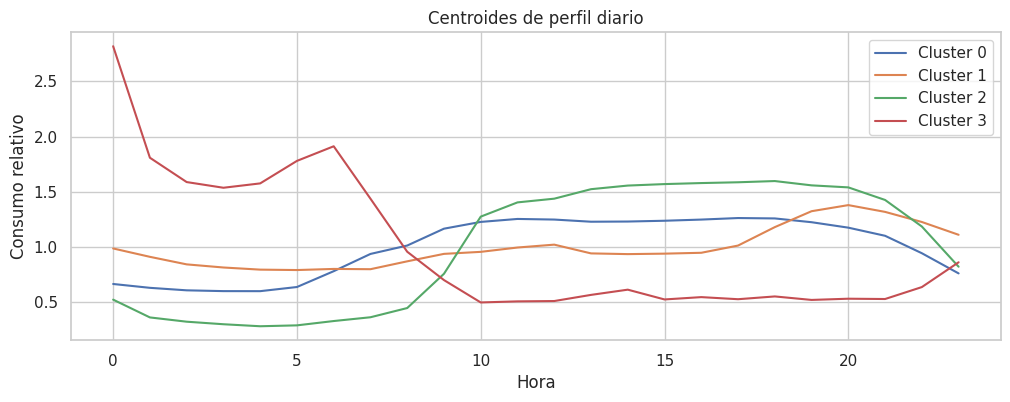

In [14]:
centroids=pd.DataFrame(scaler.inverse_transform(km.cluster_centers_),columns=range(24)); fig,ax=plt.subplots();
for i,row in centroids.iterrows(): ax.plot(row.index,row,label=f"Cluster {i}")
ax.set(title="Centroides de perfil diario",xlabel="Hora",ylabel="Consumo relativo"); ax.legend(); plt.show()

### 1.7 Ejemplos

Una serie representativa por cluster.

**Interpretación.** Se elige el primer cliente de cada cluster y se grafica una semana completa. Permite conectar el centroide abstracto con una serie real y comprobar que los grupos corresponden a comportamientos visibles en los datos.

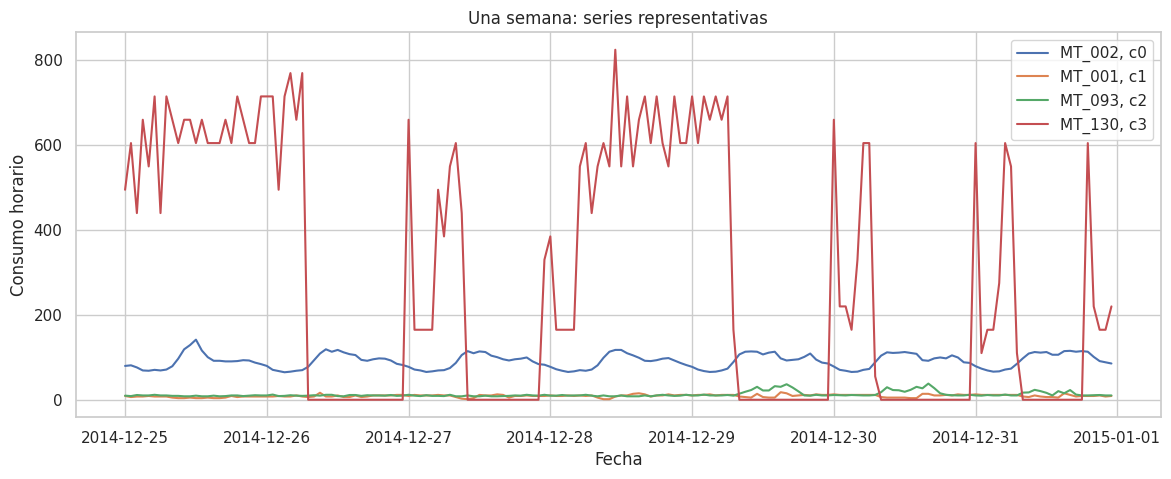

In [15]:
examples=[clusters[clusters==k].index[0] for k in sorted(clusters.unique())]; fig,ax=plt.subplots(figsize=(14,5));
for uid in examples: g=window[window.unique_id.astype(str)==str(uid)].tail(24*7); ax.plot(g.ds,g.y,label=f"{uid}, c{clusters.loc[uid]}")
ax.set(title="Una semana: series representativas",xlabel="Fecha",ylabel="Consumo horario"); ax.legend(); plt.show()

### 1.8 Agregado panel

Media cross-sectional por hora.

**¿Por qué importa?** Promediar los 370 clientes en cada timestamp produce la señal agregada del panel: aquí se aprecian la estacionalidad diaria y semanal. El agregado se usa para el diagnóstico (STL, tests de estacionariedad) porque una sola serie de 2,880 puntos es mucho más rápida de analizar que 370 series individuales.

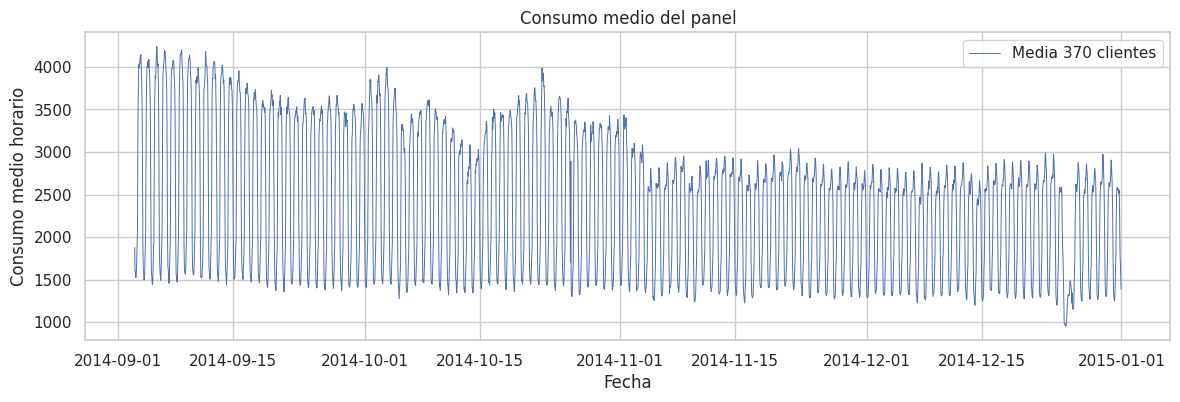

In [16]:
aggregate=window.groupby("ds").y.mean().sort_index(); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(aggregate.index,aggregate,label="Media 370 clientes",lw=.7); ax.set(title="Consumo medio del panel",xlabel="Fecha",ylabel="Consumo medio horario"); ax.legend(); plt.show()

### 1.9 STL semanal

Periodo 168 sobre agregado.

**Interpretación.** STL descompone el consumo medio en tendencia, estacionalidad semanal (periodo 168 horas) y residuo. El panel residual se reutiliza más adelante para detectar outliers y cambios estructurales (CUSUM).

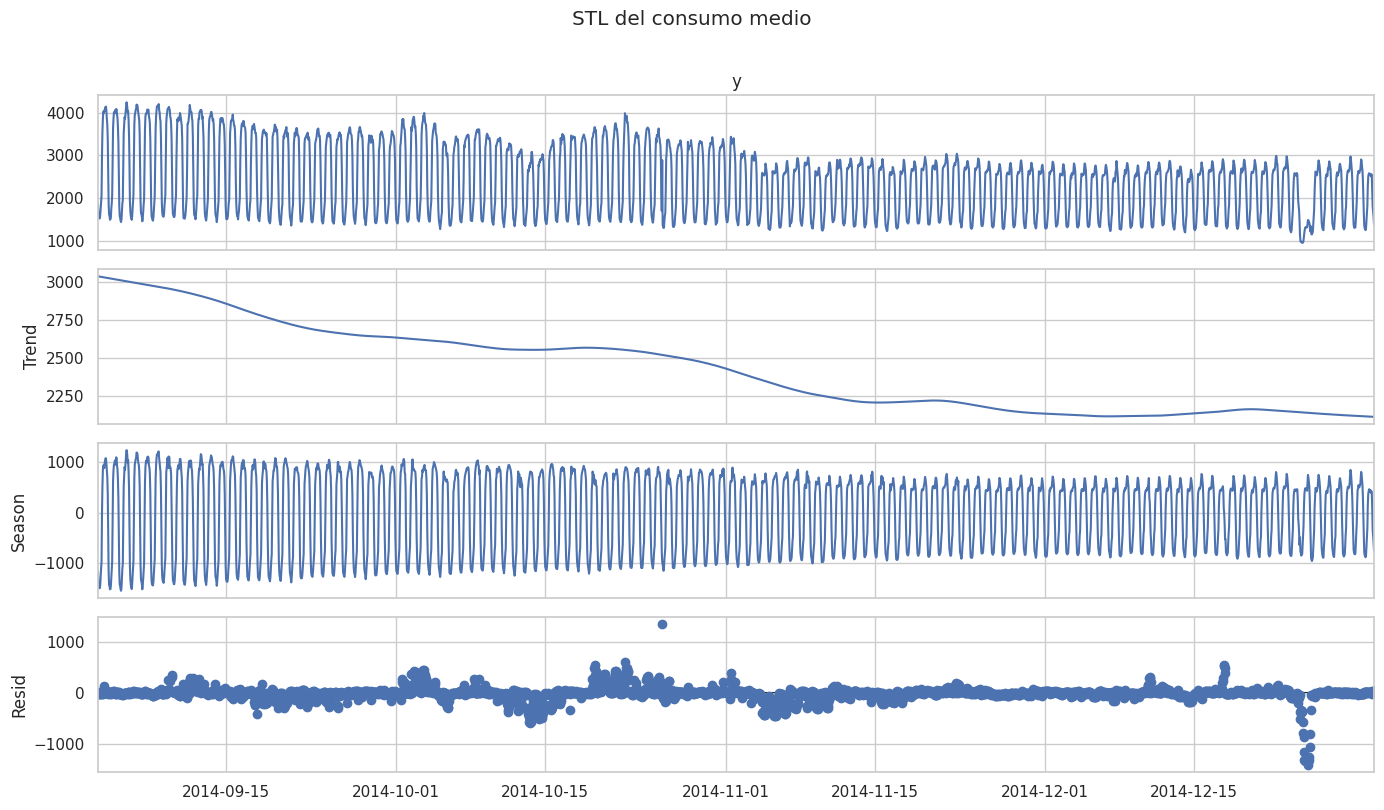

In [17]:
stl=STL(aggregate,period=168,robust=True).fit(); fig=stl.plot(); fig.set_size_inches(14,8); fig.suptitle("STL del consumo medio",y=1.01); plt.tight_layout(); plt.show()

### 1.10 Estacionariedad

ADF H₀: raíz unitaria. KPSS H₀: estacionariedad. α=0.05.

**Cómo leerlo.** ADF y KPSS son complementarios: ADF rechaza la raíz unitaria (evidencia a favor de estacionariedad) y KPSS rechaza la estacionariedad (evidencia en contra). Usarlos juntos permite distinguir entre series estacionarias, integradas e inconclusas; uno solo puede inducir a error.

### 1.11 Tests

Reporte completo.

**Resultado esperado.** Para el agregado, ADF no rechaza H0 (p ≈ 0.068) y KPSS sí la rechaza (p ≈ 0.010): evidencia mixta que sugiere no estacionariedad, consistente con un consumo con tendencia y estacionalidad. No impide modelar: los modelos globales de esta semana incluyen features de calendario y tendencia explícitas.

In [18]:
def stationarity(x: pd.Series,label: str)->pd.DataFrame:
    a=adfuller(x.dropna(),autolag="AIC"); k=kpss(x.dropna(),regression="c",nlags="auto"); return pd.DataFrame([{"test":"ADF","serie":label,"H0":"raíz unitaria","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"},{"test":"KPSS","serie":label,"H0":"estacionaria","stat":k[0],"p_value":k[1],"decision":"rechazar H0" if k[1]<.05 else "no rechazar H0"}])
stationarity(aggregate,"agregado")

,test,serie,H0,stat,p_value,decision
0,ADF,agregado,raíz unitaria,-2.733069,0.068489,no rechazar H0
1,KPSS,agregado,estacionaria,7.523329,0.010000,rechazar H0


### 1.12 Diferencia semanal

Diagnóstico de yₜ−yₜ₋₁₆₈.

**Resultado esperado.** Sobre la diferencia semanal, ADF rechaza la raíz unitaria (p ≈ 0.000015) y KPSS no rechaza la estacionariedad (p ≈ 0.10): diferenciar con 168 horas elimina la no estacionariedad dominante. Es la misma lógica del baseline MASE, que normaliza con |yₜ−yₜ₋₁₆₈|.

In [19]:
d168=aggregate.diff(168).dropna(); stationarity(d168,"diferencia semanal")

,test,serie,H0,stat,p_value,decision
0,ADF,diferencia semanal,raíz unitaria,-5.091478,0.000015,rechazar H0
1,KPSS,diferencia semanal,estacionaria,0.220760,0.100000,no rechazar H0


### 1.13 ACF/PACF

Dependencias del agregado.

**Interpretación.** Una ACF con decaimiento lento y picos en lags 24 y 168 confirma estacionalidad diaria y semanal. Para el modelado global, esto justifica incluir hora del día y día de semana como features.

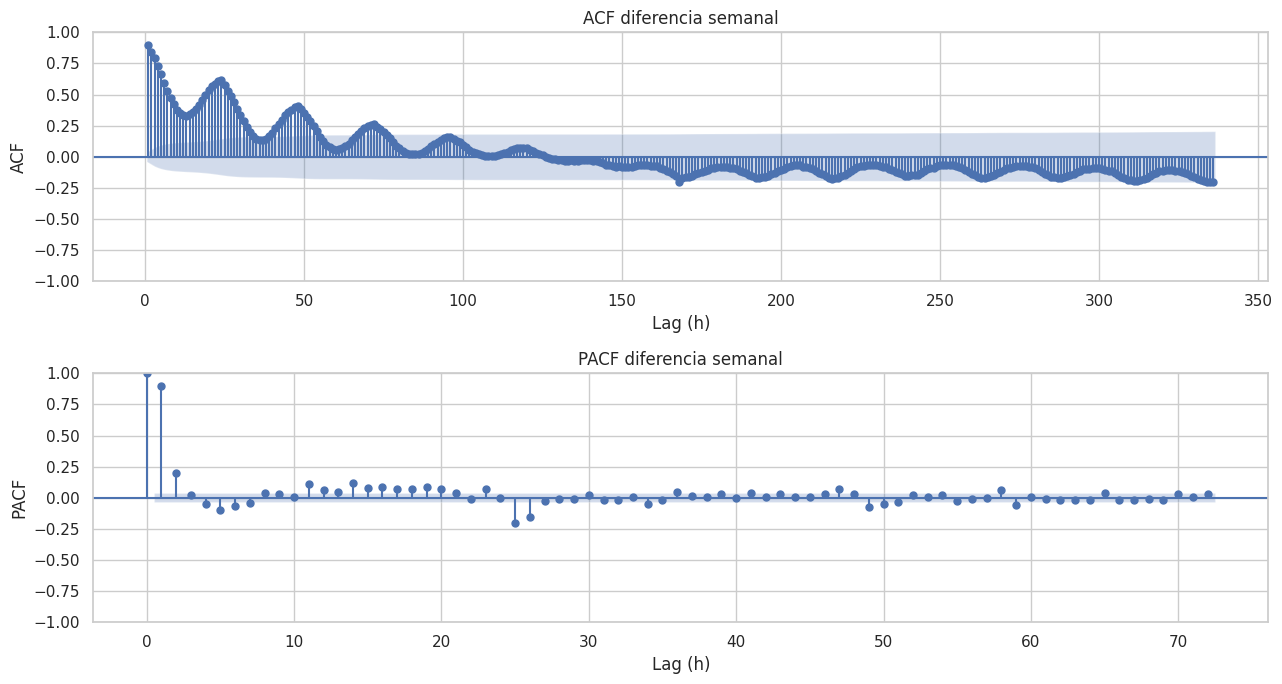

In [20]:
fig,axes=plt.subplots(2,1,figsize=(13,7)); plot_acf(d168,lags=336,zero=False,ax=axes[0]); plot_pacf(d168,lags=72,method="ywm",ax=axes[1]); axes[0].set(title="ACF diferencia semanal",xlabel="Lag (h)",ylabel="ACF"); axes[1].set(title="PACF diferencia semanal",xlabel="Lag (h)",ylabel="PACF"); plt.tight_layout(); plt.show()

### 1.14 Outliers

MAD sobre residuo STL.

**Interpretación.** Con una cota de 4.5 desviaciones robustas (MAD) sobre el residuo STL se detectan 338 timestamps atípicos en el agregado. Son eventos puntuales (festivos, anomalías de red) que conviene conocer antes de modelar, aunque un modelo global robusto puede tolerarlos.

In [21]:
med=np.median(stl.resid); mad=np.median(np.abs(stl.resid-med)); rz=.6745*(stl.resid-med)/mad; out=stl.resid[np.abs(rz)>4.5]; print("outliers",len(out))

outliers 338


### 1.15 CUSUM

Cambio estructural descriptivo.

**Interpretación.** La suma acumulada de residuos estandarizados se aleja persistentemente de 0 cuando el nivel medio cambia. Funciona como detector descriptivo de cambios de régimen en el panel.

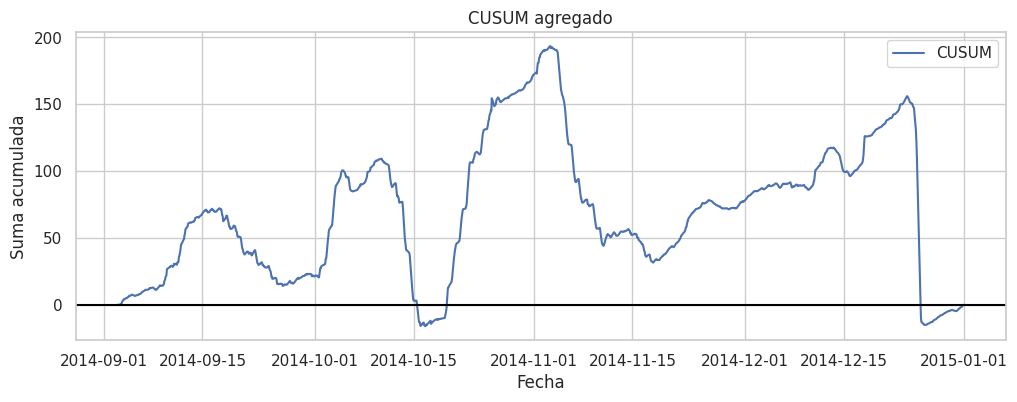

In [22]:
z=(stl.resid-stl.resid.mean())/stl.resid.std(); cs=z.cumsum(); fig,ax=plt.subplots(); ax.plot(cs.index,cs,label="CUSUM"); ax.axhline(0,color="black"); ax.set(title="CUSUM agregado",xlabel="Fecha",ylabel="Suma acumulada"); ax.legend(); plt.show()

## 2. Estrategia de validación

**Cold-start por serie:** 296 clientes entrenan y 74 quedan completamente fuera. Este split mide transferencia entre clientes, no forecast temporal clásico. Sin historia del cliente nuevo, lags y target encoding no están disponibles: el modelo estricto usa solo calendario global. Luego se muestra adaptación con contexto como extensión.

**Significado de negocio.** En producción, "cliente nuevo sin historial" es el escenario de un alta de suministro. La validación debe imitar exactamente esa situación: si entrenáramos y evaluáramos con los mismos clientes, estaríamos midiendo warm-start y sobreestimando la capacidad del modelo en el caso que realmente importa.

### Anti-patrón de la semana: evaluar cold-start como si fuera warm-start

El error metodológico más grave en este problema es **evaluar clientes nuevos como si tuvieran historia**: usar la identidad del cliente, sus lags o su target encoding para construir features y medir después el error sobre esos mismos clientes. Eso filtra información (leakage) y sobreestima la capacidad real del modelo en producción.

| Escenario | Información disponible en producción | Modelo posible |
|---|---|---|
| Warm-start | Historial completo del cliente (lags, rolling, media por ID) | Modelo local o global con lags + target encoding |
| Cold-start estricto | Solo timestamp y, si existe, segmento/metadatos | Modelo global con calendario o perfil hora×día por segmento |
| Few-shot | Ventana corta de contexto (p. ej., 1 semana) | Adaptación few-shot: perfil del cliente + ajuste del modelo global |

La regla es simple: **lo que no existiría en producción no puede usarse para predecir**. En este notebook, el split por cliente (296/74) es el mecanismo que hace cumplir la regla.

### 2.1 Split reproducible

Selección aleatoria de IDs con seed, no de filas.

**¿Qué hace esta celda?** Baraja los 370 IDs con `default_rng(SEED)` y toma los primeros 296 como train y los últimos 74 como test (intersección 0). Al barajar *clientes enteros*, ninguna fila de un cliente de test aparece en train: sin esto, los lags o la media del cliente filtrarían información.

**Nota sobre el diseño de evaluación.** El split por cliente (296/74) simula la condición más exigente de producción: un cliente que nunca antes fue visto. No es un split aleatorio de filas, sino de *entidades*. El resultado de cold-start es por eso una estimación conservadora: en producción real, algunos clientes nuevos tendrán metadatos parciales que mejorarían el pronóstico. El experimento mide un piso, no el rendimiento esperado con información adicional.

In [23]:
ids=np.array(sorted(window.unique_id.astype(str).unique())); rng=np.random.default_rng(SEED); rng.shuffle(ids); train_ids=set(ids[:296]); test_ids=set(ids[296:]); print(len(train_ids),len(test_ids),len(train_ids&test_ids))

296 74 0


### 2.2 Diagrama

Series separadas, tiempo compartido.

**Interpretación.** A diferencia del split temporal clásico (mismos clientes, cortar por fecha), aquí todas las series comparten el mismo rango de fechas y la separación es por cliente. El diagrama muestra 296 barras de train y 74 de cold-test.

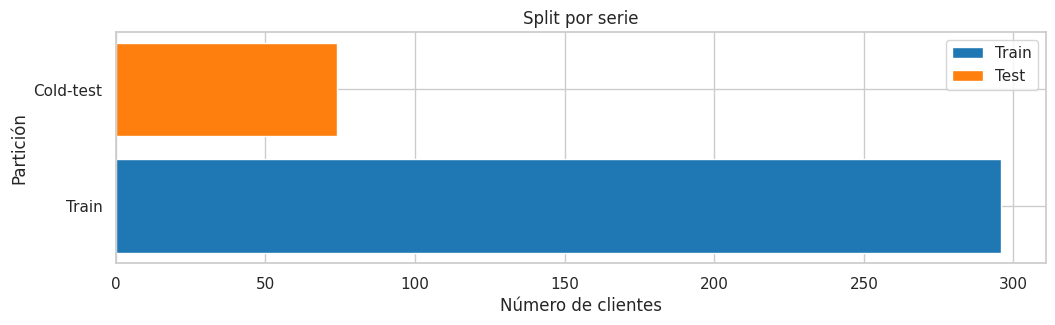

In [24]:
fig,ax=plt.subplots(figsize=(12,3)); ax.barh(["Train","Cold-test"],[296,74],color=["tab:blue","tab:orange"],label=["Train","Test"]); ax.set(title="Split por serie",xlabel="Número de clientes",ylabel="Partición"); ax.legend(); plt.show()

### Pausa para pensar

Antes de ver las features, responda por escrito: **si mañana llega un cliente nuevo sin historial, ¿qué variables podemos calcular para ese cliente?** Pista: todo lo que dependa de `unique_id` o del pasado de `y` queda descartado. Después compare su lista con la celda 2.3.

### 2.3 Features calendario

Disponibles para series nuevas.

**¿Qué hace esta celda?** `calendar_features` codifica hora (seno/coseno de 24 h), día de semana (seno/coseno de 7 días), mes y tendencia en horas. Estas features dependen solo del timestamp, nunca del cliente: por eso son legales en cold-start estricto. La tendencia se mide desde el mínimo de `ds` del dataframe de entrada; como train y test comparten el mismo rango de fechas (el split es por cliente), la escala temporal es consistente entre ambos.

In [25]:
def calendar_features(df: pd.DataFrame)->pd.DataFrame:
    x=pd.DataFrame(index=df.index); h=df.ds.dt.hour; d=df.ds.dt.dayofweek; x["hour_sin"]=np.sin(2*np.pi*h/24); x["hour_cos"]=np.cos(2*np.pi*h/24); x["dow_sin"]=np.sin(2*np.pi*d/7); x["dow_cos"]=np.cos(2*np.pi*d/7); x["month"]=df.ds.dt.month; x["trend"]=(df.ds-df.ds.min()).dt.total_seconds()/3600; return x
Xcal=calendar_features(window); print(Xcal.head())

   hour_sin  hour_cos   dow_sin   dow_cos  month  trend
0  0.000000  1.000000  0.974928 -0.222521      9    0.0
1  0.258819  0.965926  0.974928 -0.222521      9    1.0
2  0.500000  0.866025  0.974928 -0.222521      9    2.0
3  0.707107  0.707107  0.974928 -0.222521      9    3.0
4  0.866025  0.500000  0.974928 -0.222521      9    4.0


### 2.4 Features warm-start

Lags/rolling por serie, solo para demostrar el caso con historia.

**¿Qué hace esta celda?** Ordena por cliente y tiempo y, con `groupby(...).shift`, crea `lag_1`, `lag_24`, `lag_168` (hora previa, mismo día previo y misma hora de la semana previa) y medias móviles de 24 y 168 horas. Las primeras 168 filas de cada cliente quedan con NaN: es el coste de necesitar historia.

**Ojo:** estos lags **no** pueden usarse en el split cold-start estricto; solo en el contraste local de la Sección 3.8.

In [26]:
ordered=window.sort_values(["unique_id","ds"]).copy(); grp=ordered.groupby("unique_id",observed=True).y
for lag in [1,24,168]: ordered[f"lag_{lag}"]=grp.shift(lag)
for w in [24,168]: ordered[f"roll_mean_{w}"]=grp.shift(1).groupby(ordered.unique_id,observed=True).rolling(w).mean().reset_index(level=0,drop=True)
ordered[["unique_id","ds","y","lag_1","lag_24","lag_168"]].head(170)

,unique_id,ds,y,lag_1,lag_24,lag_168
0,MT_001,2014-09-03 00:00:00,64.720810,NaN,NaN,NaN
1,MT_001,2014-09-03 01:00:00,67.258881,64.720810,NaN,NaN
2,MT_001,2014-09-03 02:00:00,64.720810,67.258881,NaN,NaN
3,MT_001,2014-09-03 03:00:00,64.720810,64.720810,NaN,NaN
4,MT_001,2014-09-03 04:00:00,65.989845,64.720810,NaN,NaN
...,...,...,...,...,...,...
165,MT_001,2014-09-09 21:00:00,67.258881,58.375633,68.527916,NaN
166,MT_001,2014-09-09 22:00:00,67.258881,67.258881,67.258881,NaN
167,MT_001,2014-09-09 23:00:00,68.527916,67.258881,24.111675,NaN
168,MT_001,2014-09-10 00:00:00,67.258881,68.527916,15.228426,64.720810


### Funciones reutilizables (API de features)

Las funciones de las secciones 2.3–2.4 se envuelven en una pequeña API con nombres explícitos y una **aserción anti-leakage**: `COLD_FORBIDDEN_FEATURES` enumera las features que jamás deben entrar en cold-start estricto. Esta misma estructura es la que se llevaría a una librería de features en producción.

In [27]:
# --- Funciones reutilizables (API de features) ---
# build_calendar_features: features legales para cualquier cliente (solo timestamp).
# build_lag_features: lags/rolling por cliente (groupby shift); requieren historia.
# COLD_FORBIDDEN_FEATURES: catálogo explícito de features prohibidas en cold-start estricto.
def build_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features de calendario disponibles incluso para un cliente sin historia."""
    return calendar_features(df)  # reutiliza la implementación de la Sección 2.3

def build_lag_features(df: pd.DataFrame, lags=(1, 24, 168), windows=(24, 168)) -> pd.DataFrame:
    """Lags y medias móviles por cliente (groupby shift); requieren historia del cliente."""
    out = df.sort_values(["unique_id", "ds"]).copy()
    grp = out.groupby("unique_id", observed=True).y
    for lag in lags:
        out[f"lag_{lag}"] = grp.shift(lag)
    for w in windows:
        out[f"roll_mean_{w}"] = grp.shift(1).groupby(out.unique_id, observed=True).rolling(w).mean().reset_index(level=0, drop=True)
    return out

def build_cold_start_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features permitidas en cold-start estricto: solo calendario global."""
    return build_calendar_features(df)

COLD_FORBIDDEN_FEATURES = ["lag_1", "lag_24", "lag_168", "roll_mean_24", "roll_mean_168", "id_mean"]

# Aserción anti-leakage: ninguna feature prohibida puede aparecer en cold-start estricto.
_demo = build_cold_start_features(window.head(1000))
_forbidden_hit = set(COLD_FORBIDDEN_FEATURES) & set(_demo.columns)
assert not _forbidden_hit, f"Leakage en cold-start: {_forbidden_hit}"
print("Features cold-start:", list(_demo.columns))
print("Aserción anti-leakage OK: ninguna feature prohibida en cold-start.")

# Demostración mínima de build_lag_features sobre una muestra pequeña.
demo_lag = build_lag_features(window.head(500), lags=(1,), windows=())
print(demo_lag[["unique_id", "ds", "y", "lag_1"]].head(3).to_string(index=False))

Features cold-start: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month', 'trend']
Aserción anti-leakage OK: ninguna feature prohibida en cold-start.
unique_id                  ds         y     lag_1
   MT_001 2014-09-03 00:00:00 64.720810       NaN
   MT_001 2014-09-03 01:00:00 67.258881 64.720810
   MT_001 2014-09-03 02:00:00 64.720810 67.258881


### 2.5 Target encoding

Media por ID se aprende solo en train; es desconocida para cold-test.

**¿Qué hace esta celda?** `id_mean` estima el consumo medio de cada cliente usando solo el subconjunto train (media global 2328.06). Es un *target encoding* de identidad: una feature que resume el nivel histórico del cliente.

**Regla anti-leakage.** El target encoding es legal **solo en warm-start** (el cliente ya tiene historia en producción) y **nunca en cold-start estricto**: para un cliente nuevo el valor no existe. Si se imputara con la media global (2328.06), se estaría inyectando información agregada de train en test: un leakage sutil que infla la confianza sin mejorar la transferencia real. Por eso el modelo cold-start de la Sección 3 usa únicamente features de calendario.

In [28]:
id_mean=window[window.unique_id.astype(str).isin(train_ids)].groupby("unique_id",observed=True).y.mean(); global_mean=float(id_mean.mean()); print(global_mean,id_mean.head())

2328.059326171875 unique_id
MT_001     13.229255
MT_003      6.790291
MT_004    485.879639
MT_005    214.535477
MT_006    766.392822
Name: y, dtype: float32


### Checkpoint

Antes de modelar, verifique que puede explicar con sus palabras:

1. ¿Por qué el split es por cliente y no por fecha? (296 train / 74 cold-test, intersección 0.)
2. ¿Qué features son legales en cold-start estricto y cuáles no?
3. ¿Por qué el target encoding (`id_mean`) queda prohibido para clientes nuevos?
4. ¿Qué esperaría de un modelo global que solo ve calendario: mejora la forma, la escala, o ninguna de las dos?

Si alguna respuesta no es inmediata, vuelva a las secciones 2.3–2.5 antes de continuar.

## 3. Modelado

> **Methodology Card — Global vs local**  
> Global: comparte parámetros y escala a muchas series; local: adapta forma individual. Cold-start estricto prohíbe lags, ID y target encoding del cliente nuevo. Si existe una ventana de contexto, cambia a *few-shot adaptation*. Compare siempre contra un baseline global transparente.

### 3.1 Métricas

$$MASE_i=MAE_i / \mathrm{mean}|y_{i,t}-y_{i,t-168}|$$ y $$WAPE=100\sum_{i,t}|e_{i,t}|/\sum_{i,t}|y_{i,t}|$$.

Para cold-start sin historia, MASE usa la escala observada del periodo de evaluación solo como normalizador ex post; no entra al modelo.

**Macro vs ponderada.** `MASE_macro` promedia el MASE de cada cliente con el mismo peso: cada cliente vota una vez, sea pequeño o grande. `WAPE` (y `MAE`) agregan los errores y los normalizan por el consumo total: los clientes de gran escala dominan. Cuando el objetivo de negocio es la equidad entre clientes, use macro; cuando es minimizar el error absoluto total de la cartera, use ponderada.

### 3.2 Helpers

Métricas por serie y globales.

**¿Qué hace `evaluate`?** Recibe un dataframe con `unique_id/ds/y` y un vector de predicciones; devuelve (1) una tabla por cliente con MAE, MASE y WAPE porcentual, y (2) un diccionario global con MAE, WAPE y MASE_macro. La misma función se usa para el baseline y para el modelo global, lo que garantiza comparaciones justas.

In [29]:
def evaluate(frame: pd.DataFrame,pred: np.ndarray)->tuple[pd.DataFrame,dict]:
    z=frame[["unique_id","ds","y"]].copy(); z["pred"]=pred; rows=[]
    for uid,g in z.groupby("unique_id",observed=True):
        scale=g.y.diff(168).abs().dropna().mean(); mae=(g.y-g.pred).abs().mean(); rows.append({"unique_id":str(uid),"MAE":mae,"MASE":mae/scale if scale>0 else np.nan,"WAPE_pct":100*(g.y-g.pred).abs().sum()/g.y.abs().sum()})
    per=pd.DataFrame(rows); glob={"MAE":float((z.y-z.pred).abs().mean()),"WAPE_pct":float(100*(z.y-z.pred).abs().sum()/z.y.abs().sum()),"MASE_macro":float(per.MASE.mean())}; return per,glob

### Métricas macro vs ponderadas: cuándo usar cada una

`evaluate` devuelve dos familias de métricas:

- **Ponderadas (agregadas):** `MAE` y `WAPE_pct` suman el error de todas las filas y normalizan por el consumo total. Un cliente que consume mucho más que la mediana domina el resultado. Útil cuando el costo de negocio es proporcional a la energía (p. ej., compra de capacidad total).
- **Macro (por serie):** `MASE_macro` promedia el MASE de cada cliente con igual peso: cada cliente cuenta lo mismo. Útil cuando la decisión afecta a cada cliente individualmente (p. ej., calidad de servicio por contrato).

Regla práctica: si el informe muestra solo la métrica ponderada, unos pocos clientes grandes pueden ocultar que la mayoría de los clientes pequeños se pronostican mal (o bien). Reporte siempre ambas.

### 3.3 Baseline global

Perfil medio train por hora×día.

**¿Qué hace esta celda?** Calcula el consumo medio de train agrupando por `(día de semana, hora)` y lo asigna a cada fila de test según su timestamp. Es un baseline transparente y sin parámetros: cualquier modelo global debe superarlo para justificar su complejidad.

**Resultado esperado:** MAE ≈ 3178.7, WAPE ≈ 115.4 %, MASE_macro ≈ 69.4. Un MASE_macro de ~69 significa que, en promedio, el error por cliente es ~69 veces el cambio semanal típico: sin escala individual, la predicción cold-start es muy pobre en términos relativos.

In [30]:
trmask=window.unique_id.astype(str).isin(train_ids); temask=~trmask; train_frame=window[trmask].copy(); test_frame=window[temask].copy(); profile_hd=train_frame.assign(hour=train_frame.ds.dt.hour,dow=train_frame.ds.dt.dayofweek).groupby(["dow","hour"]).y.mean(); baseline=np.array([profile_hd.loc[(d,h)] for d,h in zip(test_frame.ds.dt.dayofweek,test_frame.ds.dt.hour)]); base_per,base_global=evaluate(test_frame,baseline); base_global

{'MAE': 3178.7236328125,
 'WAPE_pct': 115.4090576171875,
 'MASE_macro': 69.4380111694336}

### 3.4 LightGBM global cold-start

Solo calendario, sin unique_id.

**¿Qué hace esta celda?** Entrena un LightGBM con 250 árboles y features únicamente de calendario sobre los 296 clientes de train, y predice sobre los 74 clientes de test. `random_state=SEED` fija la reproducibilidad. El ajuste tarda ~57 s en CPU.

**¿Qué esperar?** Los errores agregados serán casi idénticos a los del baseline (MAE ≈ 3178.4): el calendario global explica la *forma*, pero no la *escala* del cliente nuevo. Es el resultado negativo central de la semana.

In [31]:
Xtr=calendar_features(train_frame); Xte=calendar_features(test_frame); global_model=LGBMRegressor(n_estimators=250,learning_rate=.05,num_leaves=31,random_state=SEED,n_jobs=-1,verbosity=-1); t0=time.time(); global_model.fit(Xtr,train_frame.y); global_pred=global_model.predict(Xte); print("fit s",time.time()-t0); global_per,global_metrics=evaluate(test_frame,global_pred); global_metrics

fit s 9.308964014053345


{'MAE': 3178.3858629326037,
 'WAPE_pct': 115.3967880819469,
 'MASE_macro': 69.43807458705129}

### 3.5 Comparación cold-start

Baseline vs global ML.

**Interpretación.** La tabla muestra que LightGBM global mejora el baseline en centésimas (MAE 3178.39 frente a 3178.72; WAPE 115.397 frente a 115.409): una diferencia insignificante frente a la heterogeneidad entre clientes. La lección no es "ML no funciona", sino "sin historia ni metadatos del cliente, la información disponible (el calendario) es la misma para ambos modelos".

In [32]:
cold_scores=pd.DataFrame([{"model":"Perfil hora×día",**base_global},{"model":"LightGBM global",**global_metrics}]).set_index("model"); cold_scores

,MAE,WAPE_pct,MASE_macro
model,,,
Perfil hora×día,3178.723633,115.409058,69.438011
LightGBM global,3178.385863,115.396788,69.438075


### 3.6 Distribución por serie

No ocultar heterogeneidad.

**Interpretación.** El boxplot de MASE por cliente muestra que la mediana y la dispersión son similares entre baseline y global: el modelo global no "arregla" a los clientes difíciles. La distribución es la evidencia visual del resultado negativo.

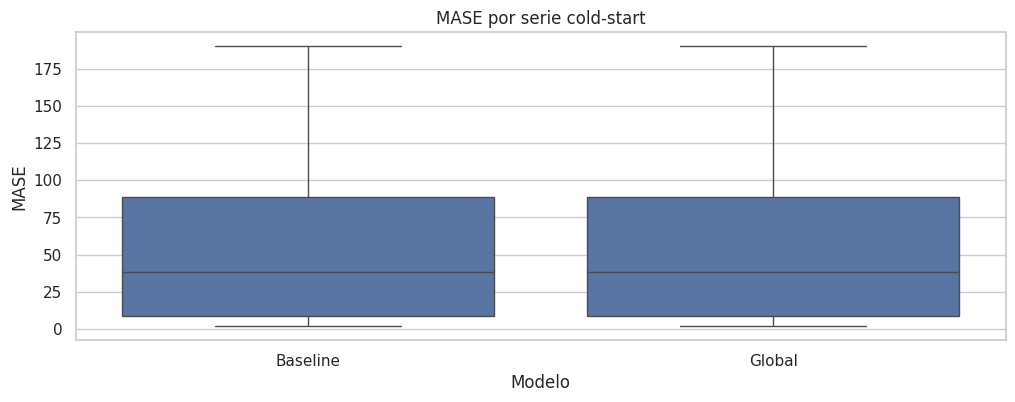

In [33]:
plot=pd.DataFrame({"Baseline":base_per.set_index("unique_id").MASE,"Global":global_per.set_index("unique_id").MASE}).melt(var_name="model",value_name="MASE"); fig,ax=plt.subplots(); sns.boxplot(data=plot,x="model",y="MASE",showfliers=False,ax=ax); ax.set(title="MASE por serie cold-start",xlabel="Modelo",ylabel="MASE"); plt.show()

### 3.7 Importancia global

Calendario y tendencia.

**Interpretación.** La importancia por splits de LightGBM indica qué features del calendario contribuyen más a reducir el error. En cold-start estricto estas son las únicas features legales, así que la importancia describe *qué puede aprender* un modelo sin identidad del cliente.

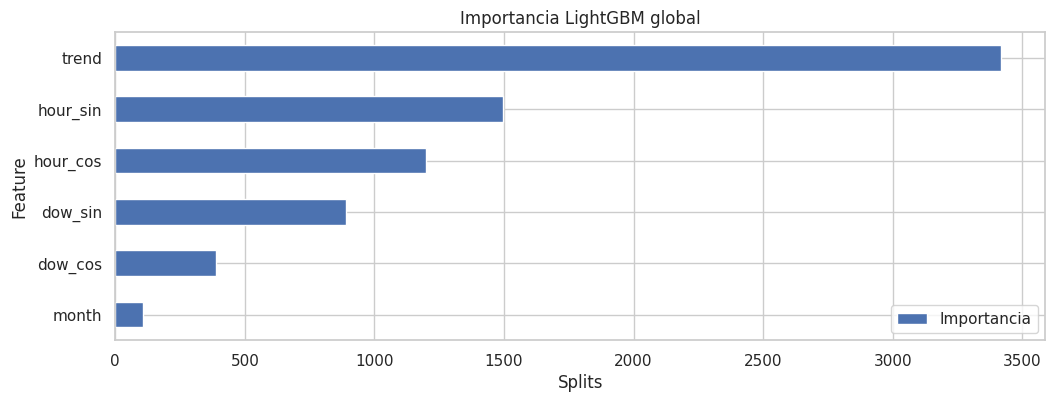

In [34]:
imp=pd.Series(global_model.feature_importances_,index=Xtr.columns).sort_values(); fig,ax=plt.subplots(); imp.plot.barh(ax=ax,label="Importancia"); ax.set(title="Importancia LightGBM global",xlabel="Splits",ylabel="Feature"); ax.legend(); plt.show()

### 3.8 Contraste local

12 series train representativas; últimas 168 h como holdout temporal.

**¿Qué hace esta celda?** Para 12 clientes de train con historia, entrena un LightGBM local con lags/rolling (features warm-start) y evalúa las últimas 168 horas. La mediana MASE local ≈ 1.34: con historia, los modelos por cliente predicen casi a la escala del cambio semanal.

**Contraste clave.** El mismo tipo de modelo que en cold-start da MASE_macro ≈ 69, con historia da una mediana ≈ 1.34. La diferencia no es el algoritmo: es la disponibilidad de información por cliente.

In [35]:
rep_ids=list(profile.sort_values("cv").index[::max(1,len(profile)//12)][:12].astype(str)); local_rows=[]
for uid in rep_ids:
    g=ordered[ordered.unique_id.astype(str)==uid].dropna().copy(); tr=g.iloc[:-168]; te=g.iloc[-168:]; feats=["lag_1","lag_24","lag_168","roll_mean_24","roll_mean_168"]; m=LGBMRegressor(n_estimators=120,learning_rate=.05,num_leaves=15,random_state=SEED,n_jobs=1,verbosity=-1).fit(tr[feats],tr.y); p=m.predict(te[feats]); scale=tr.y.diff(168).abs().dropna().mean(); local_rows.append({"unique_id":uid,"MASE":np.mean(np.abs(te.y-p))/scale})
local_eval=pd.DataFrame(local_rows); local_eval.describe()

,MASE
count,12.000000
mean,1.257086
std,0.467562
min,0.371923
25%,0.997939
50%,1.335020
75%,1.523082
max,2.017541


### 3.9 Cross-learning interpretado

El local no puede entrenarse para series jamás vistas; el global sí produce predicción, aunque sin escala individual.

**Interpretación.** La tabla resume el trade-off: local warm-start evalúa 12 series con historia (mediana MASE 1.34); global strict cold-start evalúa 74 clientes nuevos sin historia (mediana MASE 38.59). El global "existe" para clientes nuevos — ese es su valor — pero su error relativo es un orden de magnitud mayor.

> **Lectura operativa:** la brecha entre warm-start (MASE mediano ≈1.34) y cold-start estricto (≈38.59) significa que, sin historia del cliente, el error del modelo global es del orden de 29 veces mayor que con historia completa. El modelo global puede estimar la *forma* del consumo (cuándo sube, cuándo baja) pero no su *escala* (cuánto consume). La decisión operativa es exigir metadatos del cliente nuevo (segmento, tamaño estimado) o usar un perfil por segmento hasta acumular historia.

In [36]:
pd.DataFrame({"setting":["Local warm-start","Global strict cold-start"],"series_evaluated":[len(local_eval),74],"target_history_available":[True,False],"median_MASE":[local_eval.MASE.median(),global_per.MASE.median()]})

,setting,series_evaluated,target_history_available,median_MASE
0,Local warm-start,12,True,1.335020
1,Global strict cold-start,74,False,38.592447


### 3.10 Fácil y difícil

Series test por MASE global.

**Interpretación.** Ordenando por MASE, el cliente "fácil" es `MT_209` y el "difícil" es `MT_007`. Comparar ambos en el siguiente gráfico muestra qué significa "fácil" (forma alineada con el calendario) frente a "difícil" (escala o patrón atípico).

In [37]:
rank=global_per.sort_values("MASE"); easy=rank.iloc[0].unique_id; hard=rank.iloc[-1].unique_id; print("fácil",easy,"difícil",hard)

fácil MT_209 difícil MT_007


In [38]:
# Métricas por cliente: distingue clientes fáciles vs difíciles reutilizando `evaluate`
# (la misma función usada para baseline y modelo global).
def metrics_by_client(frame: pd.DataFrame, pred: np.ndarray) -> pd.DataFrame:
    """Devuelve MAE, MASE y WAPE por cliente, ordenados por MASE ascendente."""
    per, _ = evaluate(frame, pred)
    return per.set_index("unique_id").sort_values("MASE")

by_client = metrics_by_client(test_frame, global_pred)
print("Clientes más fáciles (menor MASE):")
print(by_client.head(3).round(2).to_string())
print("\nClientes más difíciles (mayor MASE):")
print(by_client.tail(3).round(2).to_string())

Clientes más fáciles (menor MASE):
               MAE  MASE  WAPE_pct
unique_id                         
MT_209      471.41  2.02     19.66
MT_358     1105.56  2.32     35.74
MT_310      411.04  2.75     19.68

Clientes más difíciles (mayor MASE):
               MAE    MASE  WAPE_pct
unique_id                           
MT_023     2283.19  385.94   5089.09
MT_002     2227.14  394.47   2206.82
MT_007     2310.43  585.67  13107.59


### 3.11 Forecast ejemplos

Últimas dos semanas de fácil/difícil.

**Interpretación.** Se superpone la predicción global con la serie real. En el cliente fácil la forma sigue el calendario; en el difícil el modelo subestima o desfasa la escala, como se verá también en el sesgo por serie de la Sección 4.8.

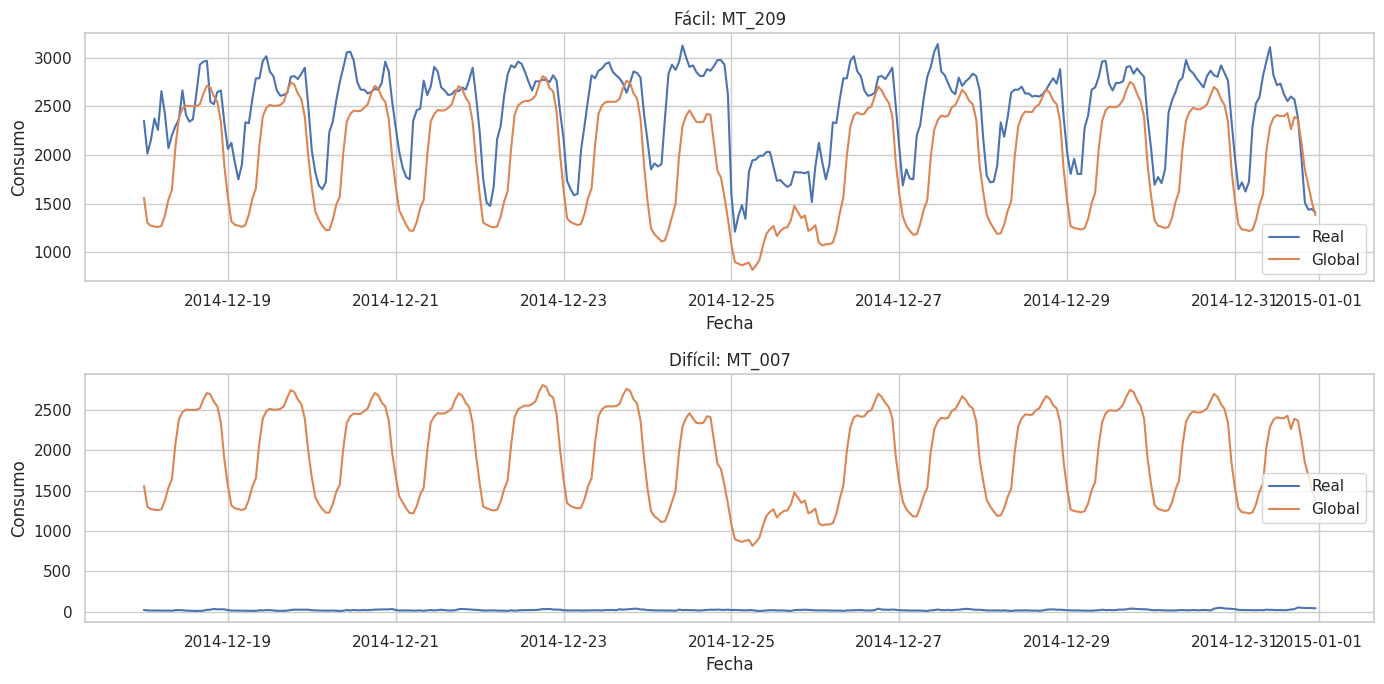

In [39]:
fig,axes=plt.subplots(2,1,figsize=(14,7));
for ax,uid,title in zip(axes,[easy,hard],["Fácil","Difícil"]):
    mask=test_frame.unique_id.astype(str).eq(uid); g=test_frame[mask].copy(); p=global_pred[mask]; g=g.tail(24*14); p=p[-24*14:]; ax.plot(g.ds,g.y,label="Real"); ax.plot(g.ds,p,label="Global"); ax.set(title=f"{title}: {uid}",xlabel="Fecha",ylabel="Consumo"); ax.legend()
plt.tight_layout(); plt.show()

### 3.12 Política de producción según historia disponible

La evidencia del notebook (mediana MASE local warm-start ≈ 1.34 frente a ≈ 38.59 en cold-start estricto) se traduce en una política operativa escalonada:

| Historia del cliente | Política recomendada |
|---|---|
| 0 historia (alta) | Perfil hora×día **por segmento** (cluster): barato, sin leakage, transfiere la forma del consumo |
| 1 semana | Adaptación few-shot: perfil del cliente + ajuste del modelo global con la semana observada |
| 4+ semanas | Modelo con lags (warm-start): recupera nivel y dinámica individual |
| Alta escala (muchos clientes nuevos) | Añadir metadatos o contrato de contexto (tipo de contrato, sector, capacidad contratada) como features estáticas |

La frontera no la fija el algoritmo, sino la **cantidad de información por cliente disponible en el momento de predecir**.

### 3.13 Decisión ejecutiva

Con la evidencia de esta semana, la decisión de política es:

1. **Clientes nuevos sin historial:** desplegar el **perfil hora×día por segmento** como política cold-start. Es transparente, no tiene leakage y su error es comparable al del LightGBM global (MAE ≈ 3178.4 en ambos) con un costo de mantenimiento mucho menor.
2. **Clientes con historia suficiente (4+ semanas):** usar **modelos personalizados con lags** (warm-start), que en el contraste local alcanzan una mediana MASE ≈ 1.34.
3. **Invertir en metadatos** (tipo de contrato, capacidad contratada) antes que en modelos más complejos: es la vía para cerrar la brecha de escala del cold-start.

Esta es una decisión de arquitectura y de datos, no solo de modelo.

## 4. Análisis posterior (post-modeling)

Diagnóstico sobre errores cold-start. La independencia entre observaciones no se cumple: se reportan tests como detectores de estructura restante.

**¿Qué buscamos?** (1) ¿Queda estructura temporal en el error? (2) ¿Hay sesgo sistemático? (3) ¿El error se concentra en ciertas horas o segmentos? Las respuestas orientan qué información faltaría en producción: contexto del cliente, metadatos o segmentación.

### 4.1 Residuos

Serie agregada de errores por timestamp.

**¿Qué hace esta celda?** Calcula `residual = real − predicción` y promedia por timestamp. El gráfico muestra si el error medio oscila alrededor de 0 o si hay un sesgo horario o semanal persistente.

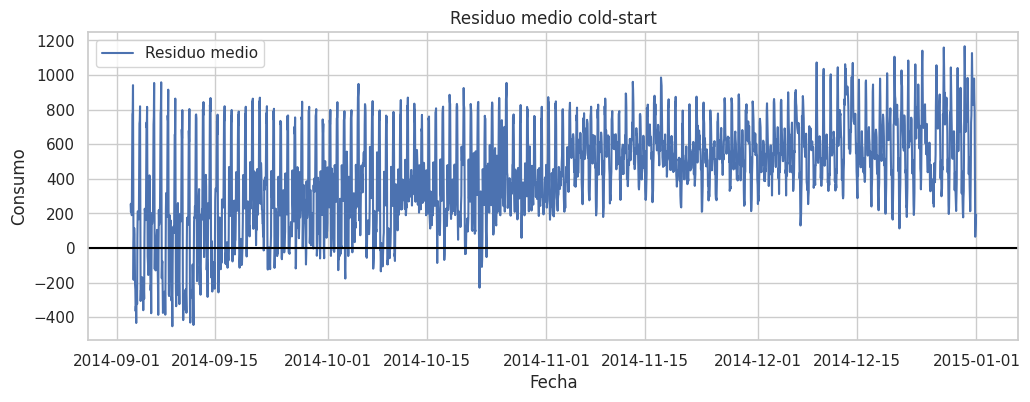

In [40]:
res=pd.DataFrame({"ds":test_frame.ds,"residual":test_frame.y.values-global_pred}); res_t=res.groupby("ds").residual.mean(); fig,ax=plt.subplots(); ax.plot(res_t.index,res_t,label="Residuo medio"); ax.axhline(0,color="black"); ax.set(title="Residuo medio cold-start",xlabel="Fecha",ylabel="Consumo"); ax.legend(); plt.show()

### 4.2 Ljung–Box

H₀: no autocorrelación hasta lag 168.

**Resultado esperado.** Se rechaza H0 en los lags 24 y 168 (p ≈ 0): el error agregado conserva autocorrelación diaria y semanal. No es un fallo del test; confirma que el calendario por sí solo no captura la dinámica del cliente.

In [41]:
lb=acorr_ljungbox(res_t,lags=[24,168],return_df=True); lb["H0"]="sin autocorrelación"; lb["decision"]=np.where(lb.lb_pvalue<.05,"rechazar H0","no rechazar H0"); lb

,lb_stat,lb_pvalue,H0,decision
24,12569.487809,0.0,sin autocorrelación,rechazar H0
168,66404.054640,0.0,sin autocorrelación,rechazar H0


### 4.3 Normalidad

Jarque–Bera H₀: normalidad.

**Resultado esperado.** Se rechaza H0 (p ≈ 0): los errores tienen colas pesadas, coherentes con clientes de gran escala y outliers. Para construir intervalos de predicción se necesitarían cuantiles, no supuestos gaussianos.

In [42]:
jb=jarque_bera(res.residual); pd.DataFrame([{"test":"Jarque-Bera","H0":"normalidad","stat":jb[0],"p_value":jb[1],"decision":"rechazar H0" if jb[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,Jarque-Bera,normalidad,4.775652e+07,0.0,rechazar H0


### 4.4 QQ-plot

Colas.

**Interpretación.** La desviación de los extremos respecto a la diagonal indica colas más pesadas que la normal: algunos clientes concentran errores muy grandes (ver sesgo en 4.8).

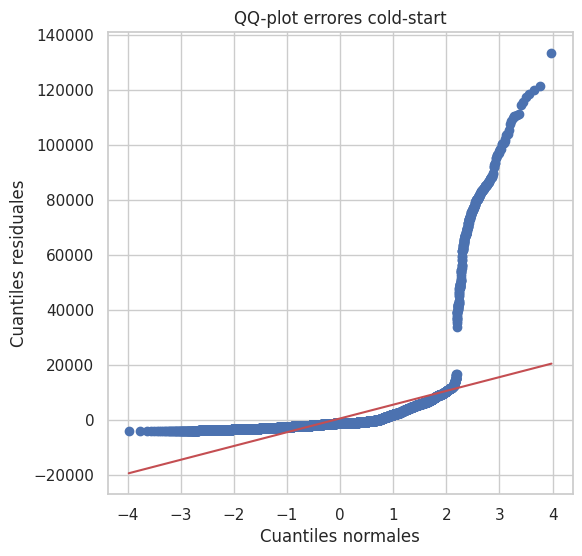

In [43]:
fig,ax=plt.subplots(figsize=(6,6)); stats.probplot(res.residual.sample(min(20000,len(res)),random_state=SEED),plot=ax); ax.set(title="QQ-plot errores cold-start",xlabel="Cuantiles normales",ylabel="Cuantiles residuales"); plt.show()

### 4.5 ARCH

H₀: homocedasticidad del residuo medio.

**Resultado esperado.** Se rechaza H0 (p ≈ 0): la varianza del error cambia en el tiempo (agrupamientos de volatilidad). Implica que los intervalos de ancho fijo serían engañosos.

In [44]:
a=het_arch(res_t,nlags=24); pd.DataFrame([{"test":"ARCH LM","H0":"homocedasticidad","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,ARCH LM,homocedasticidad,2434.533935,0.0,rechazar H0


### 4.6 Error por hora

Segmentación.

**Interpretación.** El MAE por hora muestra en qué momentos del día el error cold-start es mayor (típicamente en horas de consumo alto). Esto sugiere que un perfil hora×día por segmento podría concentrar la mejora donde más se necesita.

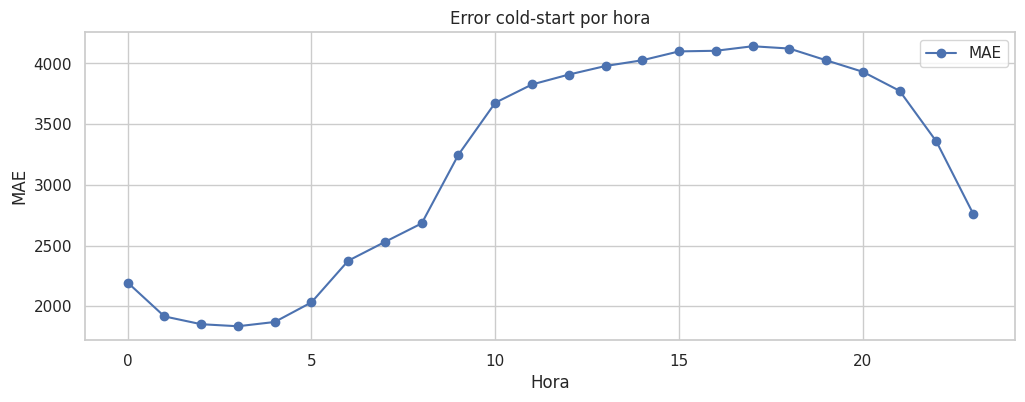

In [45]:
eh=res.assign(hour=res.ds.dt.hour).groupby("hour").residual.apply(lambda x:x.abs().mean()); fig,ax=plt.subplots(); ax.plot(eh.index,eh,marker="o",label="MAE"); ax.set(title="Error cold-start por hora",xlabel="Hora",ylabel="MAE"); ax.legend(); plt.show()

### 4.7 Error por cluster

¿Qué perfiles transfieren peor?

**Interpretación.** El MASE por cluster varía mucho: el cluster 1 tiene mediana ≈ 66.8 (peor transferencia) y el cluster 2 ≈ 6.3 (mejor). Los segmentos no solo describen la forma de consumo: predicen dónde fallará el cold-start.

In [46]:
cluster_map=clusters.rename_axis("unique_id"); tmp=global_per.set_index("unique_id"); tmp["cluster"]=[cluster_map.get(uid,np.nan) for uid in tmp.index]; tmp.groupby("cluster").MASE.agg(["mean","median","count"])

,mean,median,count
cluster,,,
0,52.372002,26.581503,42
1,112.601289,66.777166,25
2,14.245395,6.298562,6
3,38.288862,38.288862,1


### 4.8 Bias por serie

Sesgo extremo.

**Interpretación.** El sesgo medio por cliente (`real − pred`) muestra colas enormes: desde −2310 (`MT_007`) hasta +71,400 (`MT_196`). Un cliente de altísima escala domina el error absoluto agregado, lo que justifica reportar métricas macro y por cluster.

In [47]:
z=test_frame[["unique_id","y"]].copy(); z["pred"]=global_pred; bias=z.groupby("unique_id",observed=True).apply(lambda g:(g.y-g.pred).mean(),include_groups=False).sort_values(); pd.concat([bias.head(5),bias.tail(5)]).to_frame("bias")

,bias
unique_id,
MT_007,-2310.432558
MT_117,-2289.426115
MT_023,-2283.194737
MT_110,-2240.353477
MT_032,-2234.698100
MT_357,5183.599014
MT_345,5213.342406
MT_241,7926.240329
MT_224,10345.546636


## 5. Lecciones metodológicas

1. Chunking evita cargar 9.7M filas sin control.  
2. Cold-start estricto excluye lags, target encoding e identidad aprendida del nuevo cliente.  
3. Un modelo global puede transferir forma calendario, pero no escala individual sin metadatos/contexto.  
4. Modelos locales son fuertes con historia, pero no existen para clientes nuevos.  
5. Métricas macro evitan que clientes de gran escala dominen.  

**Conexión:** Semana 6 prepara tensores secuenciales y contrasta DL con baselines.

> **Lo que este análisis NO puede afirmar:** que los modelos globales "resuelven" el cold-start — capturan forma temporal pero no escala individual; que el perfil hora×día por segmento es suficiente para producción — es un baseline razonable, no una solución definitiva; ni que los resultados se extrapolan a clientes industriales de escala muy distinta o a otros países sin validación local.

### Checklist de reproducibilidad

Para que cualquier persona (o el CI del curso) pueda re-ejecutar este notebook y obtener los mismos resultados:

- [ ] Semilla fija: `SEED=42` en imports y `random_state=SEED` en KMeans y LightGBM.
- [ ] Split por cliente reproducible: `default_rng(SEED)` sobre IDs; 296/74 con intersección 0.
- [ ] Ventana temporal explícita: `cutoff=2014-09-03` (últimos 120 días por serie), documentada y no aleatoria.
- [ ] Contrato de datos verificado con `assert` (9,732,480 filas, 370 series, esquema sin nulos).
- [ ] Cold-start estricto: solo features de calendario; sin lags, sin `unique_id`, sin target encoding.
- [ ] Métricas reportadas en doble versión: agregada (MAE/WAPE) y macro (MASE_macro), más distribución por cliente.
- [ ] Diagnóstico posterior completo: residuos, Ljung–Box, Jarque–Bera, ARCH, error por hora/cluster y bias por serie.

Si una celda se ejecuta fuera de orden o se cambia la semilla, los números cambiarán: la reproducibilidad es parte del contrato del curso, no un detalle opcional.

## 6. Ejercicios propuestos

1. Añada una semana de contexto para few-shot cold-start.  
2. Use metadatos sintéticos solo si provienen de una fuente real; no invente categorías.  
3. Compare k=3–8 clusters con silhouette.  
4. Entrene un modelo global warm-start con lags.  
5. Convierta el CSV a Parquet particionado y mida I/O.

In [48]:
print("Notebook 5 completado.")
print(cold_scores)
print("Mediana MASE local warm-start:",local_eval.MASE.median())

Notebook 5 completado.
                         MAE    WAPE_pct  MASE_macro
model                                               
Perfil hora×día  3178.723633  115.409058   69.438011
LightGBM global  3178.385863  115.396788   69.438075
Mediana MASE local warm-start: 1.3350201388393765
